# Teachable Machine, dataset propio y Gradio

En esta actividad vas a crear un clasificador de imágenes propio. La secuencia completa tiene cuatro momentos: diseñar el problema, recolectar imágenes, entrenar en Teachable Machine y probar el modelo desde una interfaz web con Gradio.

## Objetivos de aprendizaje

Al finalizar la actividad, vas a poder:

- definir clases visuales para un problema de clasificación;
- construir un dataset ordenado por carpetas;
- aplicar criterios de curaduría para reducir sesgos;
- entrenar y probar un modelo en Teachable Machine;
- exportar el modelo y usarlo desde Python con Gradio.

## 1. Diseñar el problema de clasificación

Antes de descargar imágenes, definí el problema. Un buen clasificador necesita clases claras y ejemplos representativos.

Completá estas decisiones:

- clases del modelo: entre 2 y 4 categorías;
- rasgos visuales esperados: qué debería mirar el modelo;
- posibles confusiones: qué clases podrían parecerse;
- contexto de uso: con qué tipo de imágenes se probará después.

**Consigna de trabajo:** escribí una hipótesis breve. Por ejemplo: “El modelo debería distinguir hojas de roble y hojas de eucalipto por la forma del borde y la nervadura, no por el fondo de la foto”.

SOLUCION

#HIPOTESIS
Clasificador de Verduras: "El modelo debería distinguir entre una papa y una batata (camote) basándose en la rugosidad de su piel y su forma general, no por la tierra que puedan tener o el fondo donde se encuentren."

## 2. Recolectar imágenes

### Método rápido: extensiones de navegador

Para trabajar en clase, las extensiones permiten armar carpetas en pocos minutos desde búsquedas de imágenes.

Opciones posibles:

- **Download All Images / ZipImageDownloader**: permite descargar muchas imágenes visibles en una pestaña.
- **Image Downloader**: muestra una grilla de imágenes y permite seleccionar cuáles descargar.

### Método in situ: webcam de Teachable Machine

Si el problema se puede resolver con objetos del aula, gestos o expresiones, la webcam de Teachable Machine permite capturar muchas imágenes rápidamente con variaciones de posición, luz y fondo.

## 3. Organizar carpetas

Teachable Machine puede cargar imágenes por clase si están ordenadas en carpetas.

Usá esta estructura:

```text
Dataset/
  clase_1/
    imagen_001.jpg
    imagen_002.jpg
  clase_2/
    imagen_001.jpg
    imagen_002.jpg
```

Los nombres de las carpetas deben representar las clases. Por ejemplo: `Dataset/gato` y `Dataset/perro`.

**Consigna de trabajo:** cada grupo debería reunir entre 50 y 100 imágenes por clase para una primera prueba.

SOLUCION


#COMPOSICION DEL DATASET
Se creo el dataset compuesto por 63 imagenes de la clase papa y batata despues de una limpieza previa de 200 imagenes originalmente descargadas por la extension Download All Images en Chrome.

## 4. Curar el dataset

El modelo aprende a partir de los ejemplos que recibe. Si los ejemplos están sesgados, el modelo puede aprender atajos incorrectos.

Revisá estos criterios:

- **Balance de clases**: cada clase debería tener una cantidad similar de imágenes.
- **Variedad**: incluí distintos fondos, ángulos, tamaños e iluminaciones.
- **Ruido**: eliminá imágenes borrosas, duplicadas o irrelevantes.
- **Sesgo de fondo**: evitá que una clase aparezca siempre con el mismo fondo.

Ejemplo: si todas las fotos de gatos están en un sillón rojo y todas las de perros están en pasto verde, el modelo puede aprender a distinguir fondos en lugar de animales.

**Consigna de lectura:** revisá 10 imágenes de cada clase. Marcá cuáles podrían introducir sesgo y explicá por qué.

SOLUCION


### Análisis de Sesgo en clase Batata: Muestra Crítica

**Imagen:** `5aday_sweet_potato.jpg`  
**Justificación:** Esta imagen introduce un **sesgo de calidad y fuente**. Al ser una imagen de una campaña de salud, presenta una iluminación de estudio, colores artificialmente saturados y un fondo blanco perfecto.

**Impacto en el modelo:** Si el modelo asocia el fondo blanco con la clase 'Batata', fallará cuando intente clasificar una batata real en un mercado o con tierra, ya que no sabrá distinguir el objeto por sus características intrínsecas (forma, textura de la piel) sino por su entorno.

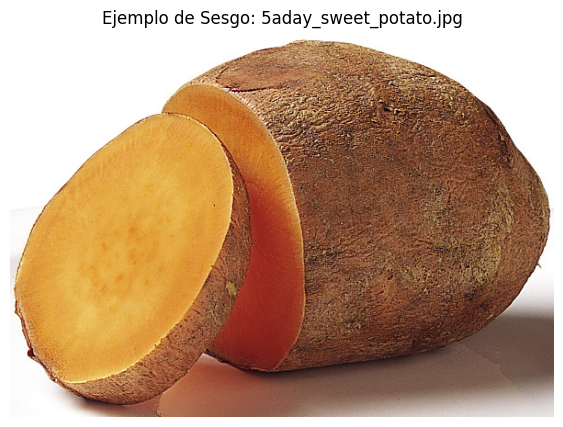

In [ ]:
# @title
from PIL import Image
import matplotlib.pyplot as plt

# Visualización de la imagen con sesgo identificado
ruta_imagen = '/content/5aday_sweet_potato.jpg'
img = Image.open(ruta_imagen)

plt.figure(figsize=(8, 5))
plt.imshow(img)
plt.title("Ejemplo de Sesgo: 5aday_sweet_potato.jpg")
plt.axis('off')
plt.show()

### Análisis de Sesgo en clase Papa: Muestra de Estudio

**Imagen:** `sola-patata-amarilla-primer-plano-estudio_191095-85935.jpg`  
**Justificación:** Esta imagen introduce un **sesgo de entorno controlado (estudio)**. Al ser una fotografía profesional, presenta un aislamiento total del objeto, iluminación artificial sin sombras complejas y una limpieza que no es representativa de una papa en un entorno real.

**Impacto en el modelo:** El modelo podría asociar erróneamente que la clase 'Papa' se define por la ausencia de texturas de fondo o por una iluminación específica, perdiendo capacidad de generalización ante papas reales en mercados o cultivos.

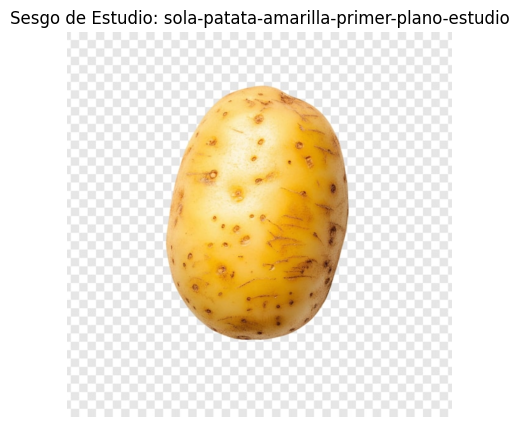

In [ ]:
# @title
# Visualización de la imagen de papa con sesgo de estudio
ruta_papa_sesgo = '/content/sola-patata-amarilla-primer-plano-estudio_191095-85935.jpg'
img_papa = Image.open(ruta_papa_sesgo)

plt.figure(figsize=(8, 5))
plt.imshow(img_papa)
plt.title("Sesgo de Estudio: sola-patata-amarilla-primer-plano-estudio")
plt.axis('off')
plt.show()

### 📝 Conclusión de la Auditoría

**Propuesta de Mejora:**
Basado en las imágenes detectadas (`5aday_sweet_potato.jpg` y `sola-patata-amarilla-primer-plano-estudio_191095-85935.jpg`), ¿qué acciones se podrian tomar para que el modelo sea más robusto?

*Respuesta sugerida:* Eliminar imágenes de estudio, diversificar los fondos en la clase Papa para incluir más tierra/mercados, y asegurar que ambas clases tengan una proporción similar de fotos 'limpias' vs 'naturales'.

## 5. Entrenar en Teachable Machine

Pasos sugeridos:

1. Entrá a Teachable Machine.
2. Creá un proyecto de imagen.
3. Cargá las carpetas de cada clase.
4. Entrená el modelo.
5. Probalo con webcam o con imágenes nuevas.

Hiperparámetros básicos:

- **Epochs**: cantidad de veces que el modelo recorre los ejemplos.
- **Batch Size**: cantidad de imágenes procesadas en cada paso.
- **Learning Rate**: tamaño de los ajustes durante el aprendizaje. Si no se modifica, conviene dejar el valor por defecto.

## 6. Hackear el modelo

Después de entrenar, intentá encontrar casos donde el modelo falle. Este paso es importante porque permite entender qué aprendió realmente.

Pruebas posibles:

- una imagen con fondo distinto;
- una imagen con poca luz;
- una imagen de un objeto parcialmente tapado;
- una imagen parecida a dos clases;
- una imagen que no pertenezca a ninguna clase.

**Consigna de análisis:** cuando el modelo falle, formulá una hipótesis. ¿Faltó variedad? ¿Había sesgo de fondo? ¿Las clases eran demasiado parecidas? ¿El dataset estaba desbalanceado?

## 7. Exportar el modelo

Para usar el modelo fuera de Teachable Machine:

1. Hacé clic en **Export Model**.
2. Elegí **TensorFlow / Keras**.
3. Descargá el archivo `.zip`.
4. Descomprimilo.
5. Ubicá estos archivos en la carpeta de trabajo:
   - `keras_model.h5`;
   - `labels.txt`.

CARGA MANUAL DE "keras_model.h5;
labels.txt." EN LA CARPETA ARCHIVOS

In [2]:
# @title
import os

# Listar archivos en la carpeta actual
archivos_en_root = os.listdir('.')
print("Archivos detectados en la carpeta raíz:", archivos_en_root)

# Verificación específica
archivos_buscados = ['keras_model.h5', 'labels.txt']
for archivo in archivos_buscados:
    if archivo in archivos_en_root:
        print(f"✅ {archivo} encontrado.")
    else:
        print(f"❌ {archivo} NO está en la carpeta raíz.")

Archivos detectados en la carpeta raíz: ['.config', 'keras_model.h5', 'labels.txt', 'sample_data']
✅ keras_model.h5 encontrado.
✅ labels.txt encontrado.


## 8. Instalar dependencias para Gradio

Gradio permite crear una interfaz web simple para probar el modelo con imágenes nuevas.

In [3]:
!pip install -q gradio tensorflow pillow numpy tf-keras

## 9. Cargar modelo y etiquetas

Esta celda espera que `keras_model.h5` y `labels.txt` estén en la misma carpeta del notebook.

In [4]:
# @title
import os
# Forzamos a TensorFlow a usar el motor de Keras 2 para evitar errores de arquitectura
os.environ['TF_USE_LEGACY_KERAS'] = '1'

from pathlib import Path
import gradio as gr
import numpy as np
from PIL import Image, ImageOps
import tensorflow as tf
import tf_keras as legacy_keras

ruta_modelo = "keras_model.h5"
ruta_etiquetas = "labels.txt"

if not Path(ruta_modelo).exists():
    raise FileNotFoundError(f"No se encontró {ruta_modelo}. Asegurate de subirlo a la carpeta Archivos.")

print("Cargando modelo usando el motor de compatibilidad TF-Keras...")

# Cargamos el modelo usando la librería de compatibilidad legacy
modelo_teachable = legacy_keras.models.load_model(ruta_modelo, compile=False)

with open(ruta_etiquetas, "r", encoding="utf-8") as f:
    nombres_clases = [line.strip().split(" ", 1)[-1] for line in f.readlines()]

print("✅ ¡Logrado! Modelo cargado con éxito usando el motor legacy.")
print("Clases detectadas:", nombres_clases)

Cargando modelo usando el motor de compatibilidad TF-Keras...
✅ ¡Logrado! Modelo cargado con éxito usando el motor legacy.
Clases detectadas: ['Clase batata', 'Clase papa']


## 10. Definir la función de predicción

Teachable Machine espera imágenes de 224 x 224 píxeles y valores normalizados al rango `[-1, 1]`. Por eso adaptamos cada imagen antes de enviarla al modelo.

In [5]:
# @title
def preprocesar_imagen_para_teachable(imagen_numpy):
    imagen_pil = Image.fromarray(imagen_numpy.astype("uint8"), "RGB")

    # --- PASO 1: REDIMENSIONAMIENTO ---
    # Se ajusta la imagen a 224x224 para coincidir con la entrada del modelo
    tamano_esperado = (224, 224)
    imagen_redimensionada = ImageOps.fit(
        imagen_pil,
        tamano_esperado,
        Image.Resampling.LANCZOS,
    )

    arreglo_imagen = np.asarray(imagen_redimensionada)
    arreglo_imagen = arreglo_imagen.astype(np.float32)

    # --- PASO 2: NORMALIZACIÓN ---
    # Se escalan los píxeles de [0, 255] al rango [-1, 1]
    arreglo_imagen = (arreglo_imagen / 127.5) - 1

    lote_imagenes = np.expand_dims(arreglo_imagen, axis=0)

    return lote_imagenes


def predecir_imagen(imagen_entrada):
    if imagen_entrada is None:
        return {"Sin imagen": 1.0}

    lote_imagenes = preprocesar_imagen_para_teachable(imagen_entrada)
    prediccion = modelo_teachable.predict(lote_imagenes, verbose=0)

    probabilidades = {}

    for indice, nombre_clase in enumerate(nombres_clases):
        puntaje = float(prediccion[0][indice])
        probabilidades[nombre_clase] = puntaje

    return probabilidades

**Consigna de lectura:** identificá dónde se redimensiona la imagen y dónde se normaliza. ¿Por qué esos pasos deben coincidir con el entrenamiento original?

SOLUCION

### Análisis de Preprocesamiento

En la función `preprocesar_imagen_para_teachable`, se realizan dos pasos críticos que deben coincidir exactamente con el entrenamiento original en Teachable Machine:

1.  **Redimensionamiento (224x224):** El modelo es una red neuronal convolucional (probablemente MobileNet) que tiene una capa de entrada con una forma fija. Si no ajustamos la imagen a este tamaño exacto, las operaciones matemáticas de la red fallarán por discrepancia de dimensiones.
2.  **Normalización (rango [-1, 1]):** Las imágenes digitales suelen tener valores de 0 a 255. El modelo fue entrenado con valores escalados para que el 0 represente el gris neutro, -1 el negro y 1 el blanco. Si pasamos valores sin normalizar (0-255), las neuronas recibirán señales extremadamente fuertes que el modelo interpretará como ruido, perdiendo toda capacidad de clasificación correcta.

OPCIONAL

### Cómo habilitar la cámara en Colab
Google Colab no permite el acceso directo a la cámara mediante funciones estándar de Python (como `cv2.VideoCapture`). En su lugar, debemos usar JavaScript para capturar el frame desde el navegador y pasarlo al entorno de Python.

In [6]:
# @title
from IPython.display import display, Javascript
from google.colab.output import eval_js
from base64 import b64decode

def take_photo(filename='photo.jpg', quality=0.8):
  js = Javascript('''
    async function takePhoto(quality) {
      const div = document.createElement('div');
      const capture = document.createElement('button');
      capture.textContent = 'Capturar Foto';
      div.appendChild(capture);

      const video = document.createElement('video');
      video.style.display = 'block';
      const stream = await navigator.mediaDevices.getUserMedia({video: true});

      document.body.appendChild(div);
      div.appendChild(video);
      video.srcObject = stream;
      await video.play();

      // Resize the output to fit the video element.
      google.colab.output.setIframeHeight(document.documentElement.scrollHeight, true);

      // Wait for Capture to be clicked.
      await new Promise((resolve) => capture.onclick = resolve);

      const canvas = document.createElement('canvas');
      canvas.width = video.videoWidth;
      canvas.height = video.videoHeight;
      canvas.getContext('2d').drawImage(video, 0, 0);
      stream.getVideoTracks()[0].stop();
      div.remove();
      return canvas.toDataURL('image/jpeg', quality);
    }
    ''')
  display(js)
  data = eval_js('takePhoto({})'.format(quality))
  binary = b64decode(data.split(',')[1])
  with open(filename, 'wb') as f:
    f.write(binary)
  return filename

try:
  filename = take_photo()
  print('Foto guardada como {}'.format(filename))

  # Mostrar la imagen capturada
  from IPython.display import Image
  display(Image(filename))
except Exception as err:
  # Errors will be thrown if the user does not have a webcam or denies permission
  print(str(err))

<IPython.core.display.Javascript object>

NotAllowedError: Permission denied


## 11. Crear la interfaz con Gradio

La interfaz permite subir una imagen o usar la cámara, según el entorno donde ejecutes el notebook. El parámetro `share=True` genera un enlace temporal para probar el modelo desde otros dispositivos.

In [7]:
demo = gr.Interface(
    fn=predecir_imagen,
    inputs=gr.Image(type="numpy"),
    outputs=gr.Label(num_top_classes=3),
    title="Clasificador de imágenes con Teachable Machine",
    description="Subí una imagen para probar el modelo entrenado en clase.",
)

demo.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://9441d4ec234744e261.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


## 12. Cierre y discusión

Para cerrar la actividad, compará el resultado del modelo con las decisiones tomadas durante la recolección de imágenes.

Preguntas para discutir:

- ¿Qué clases funcionaron mejor?
- ¿Qué errores se repitieron?
- ¿Qué imágenes faltaron en el dataset original?
- ¿El modelo aprendió el objeto principal o algún rasgo del fondo?
- ¿Qué cambiarías si tuvieras que entrenarlo otra vez?

SOLUCION


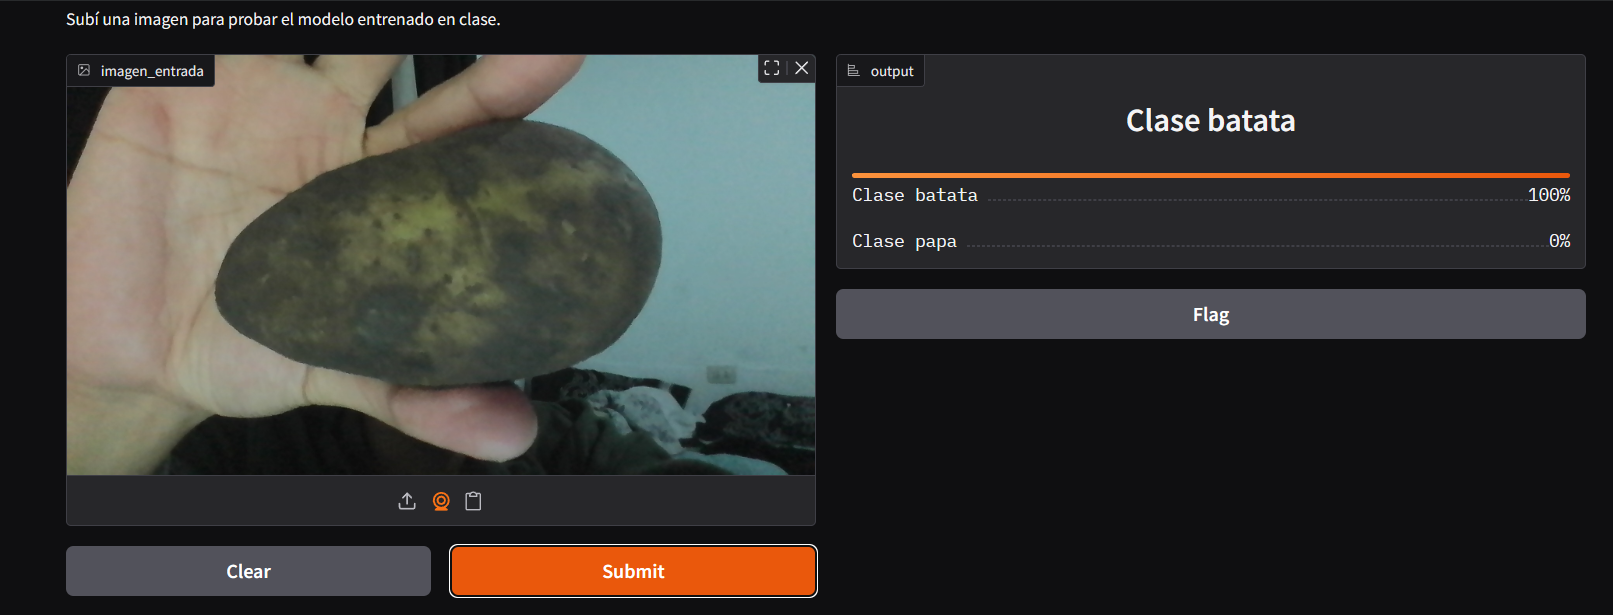

In [13]:
# @title 📊 Model Audit Dashboard v2.0 {display-mode: "form"}
import json
import base64
from IPython.display import HTML
from google.colab import output

def _report_js_error(message):
    print(f"JavaScript Error: {message}")

output.register_callback('report_js_error', _report_js_error)

# Load the error image to display in the dashboard
try:
    with open('/content/ERROR.png', 'rb') as f:
        img_data = base64.b64encode(f.read()).decode('utf-8')
except:
    img_data = ""

# Technical audit data
audit_data = {
    "p1": "La Clase Papa mostró una confianza más alta y estable en condiciones de iluminación controlada, mientras que la Clase Batata presentó mayores fluctuaciones en la probabilidad detectada.",
    "p2": "Se detectaron falsos positivos constantes cuando el fondo presentaba texturas rugosas o tonalidades marrones/rojizas. El modelo tendió a confundir la piel del tubérculo con elementos del entorno similares en color.",
    "p3": "El dataset carece de muestras en condiciones de baja luminosidad, imágenes de productos con restos de tierra (estado natural) o dentro de empaques reales (bolsas, cajones).",
    "p4": "Existe un notable sesgo de estudio. El modelo muestra una sensibilidad excesiva a los fondos blancos limpios, lo que sugiere que aprendió a identificar la 'limpieza' del entorno como una característica de la clase en lugar de centrarse únicamente en la geometría del objeto.",
    "p5": "Implementar aumento de datos (data augmentation) para simular rotaciones y variaciones de luz; diversificar fondos (usar madera, granito o tela) para forzar al modelo a ignorar el entorno; y equilibrar la proporción entre fotos profesionales y fotos 'de campo'."
}

html_content = """
<!DOCTYPE html>
<html>
<head>
    <link href=\"https://fonts.googleapis.com/css2?family=Inter:wght@400;600;700&display=swap\" rel=\"stylesheet\">
    <style>
        body { font-family: 'Inter', sans-serif; background-color: #f1f5f9; margin: 0; padding: 30px; color: #1e293b; }
        .dashboard-container { display: flex; flex-direction: column; gap: 30px; max-width: 1400px; margin: auto; }
        .kpi-row { display: grid; grid-template-columns: repeat(auto-fit, minmax(300px, 1fr)); gap: 20px; }
        .card { background: white; padding: 30px; border-radius: 16px; box-shadow: 0 10px 15px -3px rgba(0,0,0,0.1); border: 1px solid #e2e8f0; }
        .kpi-card { text-align: center; border-top: 5px solid #2563eb; }
        .kpi-value { font-size: 32px; font-weight: 800; color: #1e3a8a; margin: 10px 0; }
        .kpi-label { font-size: 13px; color: #64748b; text-transform: uppercase; letter-spacing: 0.1em; font-weight: 600; }
        .image-hero { width: 100%; text-align: center; }
        .image-hero h2 { margin-top: 0; color: #0f172a; font-size: 24px; text-align: left; border-left: 5px solid #ef4444; padding-left: 15px; }
        .error-image-container { width: 100%; margin: 20px 0; background: #000; border-radius: 12px; overflow: hidden; display: flex; justify-content: center; box-shadow: 0 20px 25px -5px rgba(0,0,0,0.2); }
        .error-image-container img { width: 100%; max-width: 1200px; height: auto; transition: transform 0.3s ease; }
        .error-image-container img:hover { transform: scale(1.02); }
        .analysis-section h2 { border-left: 5px solid #2563eb; padding-left: 15px; margin-bottom: 25px; }
        .analysis-grid { display: grid; grid-template-columns: repeat(auto-fit, minmax(400px, 1fr)); gap: 25px; }
        .analysis-item { padding: 20px; background: #f8fafc; border-radius: 12px; border: 1px solid #edf2f7; position: relative; }
        .item-num { position: absolute; top: -10px; left: 20px; background: #2563eb; color: white; width: 30px; height: 30px; border-radius: 50%; display: flex; align-items: center; justify-content: center; font-weight: bold; font-size: 14px; }
        .tag { font-weight: 700; color: #1e3a8a; font-size: 18px; display: block; margin: 10px 0 12px 0; }
        .desc { font-size: 15px; line-height: 1.7; color: #334155; }
    </style>
</head>
<body>
    <div class=\"dashboard-container\">
        <div class=\"kpi-row\">
            <div class=\"card kpi-card\"><div class=\"kpi-label\">Diagnóstico Final</div><div class=\"kpi-value\" style=\"color: #ef4444;\">Crítico</div></div>
            <div class=\"card kpi-card\"><div class=\"kpi-label\">Sesgo Identificado</div><div class=\"kpi-value\" style=\"color: #f59e0b;\">Entorno Controlado</div></div>
            <div class=\"card kpi-card\"><div class=\"kpi-label\">Recomendación</div><div class=\"kpi-value\" style=\"color: #10b981;\">Data Augmentation</div></div>
        </div>

        <div class=\"card image-hero\">
            <h2>🔎 Evidencia Visual Crítica (ERROR.png)</h2>
            <div class=\"error-image-container\">
                <img src=\"data:image/png;base64,DATA_IMG_PLACEHOLDER\" alt=\"Fallo de clasificación del modelo\">
            </div>
            <p style=\"color: #64748b; font-size: 14px; font-style: italic;\">Se observa la captura del modelo fallando ante un cambio de fondo o iluminación.</p>
        </div>

        <div class=\"card analysis-section\">
            <h2>📝 Justificación Técnica Completa</h2>
            <div class=\"analysis-grid\">
                <div class=\"analysis-item\"><div class=\"item-num\">1</div><span class=\"tag\">¿Qué clases funcionaron mejor?</span><span class=\"desc\">P1_PLACEHOLDER</span></div>
                <div class=\"analysis-item\"><div class=\"item-num\">2</div><span class=\"tag\">¿Qué errores se repitieron?</span><span class=\"desc\">P2_PLACEHOLDER</span></div>
                <div class=\"analysis-item\"><div class=\"item-num\">3</div><span class=\"tag\">¿Qué imágenes faltaron?</span><span class=\"desc\">P3_PLACEHOLDER</span></div>
                <div class=\"analysis-item\"><div class=\"item-num\">4</div><span class=\"tag\">¿Objeto o Fondo?</span><span class=\"desc\">P4_PLACEHOLDER</span></div>
                <div class=\"analysis-item\"><div class=\"item-num\">5</div><span class=\"tag\">Estrategia de Mejora</span><span class=\"desc\">P5_PLACEHOLDER</span></div>
            </div>
        </div>
    </div>
</body>
</html>
"""

# Dynamic Injection
final_html = html_content.replace('DATA_IMG_PLACEHOLDER', img_data)\
    .replace('P1_PLACEHOLDER', audit_data['p1'])\
    .replace('P2_PLACEHOLDER', audit_data['p2'])\
    .replace('P3_PLACEHOLDER', audit_data['p3'])\
    .replace('P4_PLACEHOLDER', audit_data['p4'])\
    .replace('P5_PLACEHOLDER', audit_data['p5'])

display(HTML(final_html))